In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Telco-Customer-dataset.csv")

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [8]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nChurn classes:")
print(df["Churn"].value_counts())

Shape: (7043, 21)

Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partn

In [9]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df = df.dropna(subset=["TotalCharges"])

In [10]:
X = df[["tenure", "MonthlyCharges", "TotalCharges"]]

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("X:")
print(X)

print("\ny:")
print(y)

X:
      tenure  MonthlyCharges  TotalCharges
0          1           29.85         29.85
1         34           56.95       1889.50
2          2           53.85        108.15
3         45           42.30       1840.75
4          2           70.70        151.65
...      ...             ...           ...
7038      24           84.80       1990.50
7039      72          103.20       7362.90
7040      11           29.60        346.45
7041       4           74.40        306.60
7042      66          105.65       6844.50

[7032 rows x 3 columns]

y:
0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64


In [11]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Missing values in X:", np.isnan(X).sum())
print("Missing values in y:", np.isnan(y).sum())

print("Classes:", np.unique(y))

X shape: (7032, 3)
y shape: (7032,)
Missing values in X: tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64
Missing values in y: 0
Classes: [0 1]


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 3)
X_test shape: (1407, 3)
y_train shape: (5625,)
y_test shape: (1407,)


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [14]:
print("Intercept (b0):", model.intercept_[0])

print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coefficient:.4f}")

Intercept (b0): -1.6268879412388848

Coefficients:
tenure: -0.0657
MonthlyCharges: 0.0306
TotalCharges: 0.0001


In [15]:
y_pred = model.predict(X_test)

print("Actual values:", y_test.values)
print("Predicted values:", y_pred)

Actual values: [0 0 0 ... 0 0 0]
Predicted values: [0 1 0 ... 0 0 0]


In [19]:
y_probability = model.predict_proba(X_test)[:, 1]

print("Churn probabilities:")
print(y_probability)

Churn probabilities:
[0.06983747 0.59483547 0.01187928 ... 0.22791802 0.06677944 0.01520659]


In [26]:
new_customer = pd.DataFrame({
    "tenure": [12],
    "MonthlyCharges": [70],
    "TotalCharges": [840]
})
prediction = model.predict(new_customer)[0]

probability_churn = model.predict_proba(new_customer)[0][1]

print("Tenure:", new_customer["tenure"][0])
print("Monthly Charges:", new_customer["MonthlyCharges"][0])
print("Total Charges:", new_customer["TotalCharges"][0])

print("Probability of Churn:", probability_churn)

print(
    "Predicted Result:",
    "Likely to Churn" if prediction == 1 else "Likely to Stay"
)


Tenure: 12
Monthly Charges: 70
Total Charges: 840
Probability of Churn: 0.45888167004775443
Predicted Result: Likely to Stay


In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.7746979388770433
Accuracy (%): 77.46979388770433


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[927 106]
 [211 163]]


In [23]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

print("\nCorrectly identified churn customers:", tp)

print(
    "Non-churn customers misclassified as churn:",
    fp
)

True Negatives: 927
False Positives: 106
False Negatives: 211
True Positives: 163

Correctly identified churn customers: 163
Non-churn customers misclassified as churn: 106


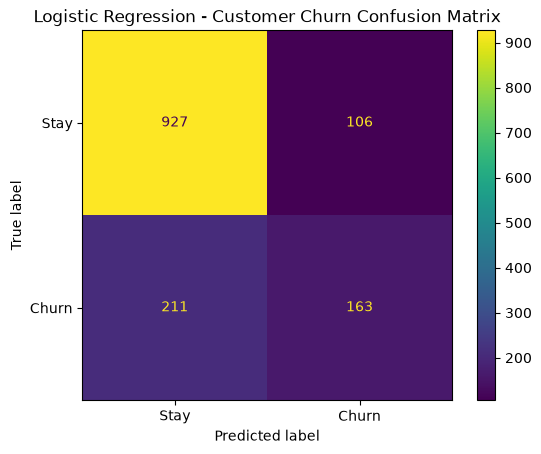

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stay", "Churn"]
).plot()

plt.title("Logistic Regression - Customer Churn Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Stay", "Churn"],
    zero_division=0
))

              precision    recall  f1-score   support

        Stay       0.81      0.90      0.85      1033
       Churn       0.61      0.44      0.51       374

    accuracy                           0.77      1407
   macro avg       0.71      0.67      0.68      1407
weighted avg       0.76      0.77      0.76      1407

